# Optuna Hyperparameter Optimization Analysis

This notebook analyzes the results of hyperparameter optimization performed using **Optuna** on an **XGBoost regression model** trained on the California Housing dataset.

The objective of this analysis is to:
- Understand the optimization behavior
- Identify the most important hyperparameters
- Compare baseline and tuned model performance
- Summarize key insights from the experiment


In [1]:
import json
import os

RESULTS_PATH = "../outputs/results.json"

with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

results


{'n_trials_completed': 100,
 'n_trials_pruned': 0,
 'best_cv_rmse': 57.39938441515227,
 'test_rmse': 52.481687230364855,
 'test_r2': 0.48013427601106184,
 'best_params': {'n_estimators': 263,
  'max_depth': 3,
  'learning_rate': 0.014780731456797414,
  'subsample': 0.6706218738980257,
  'colsample_bytree': 0.6577793023436785,
  'min_child_weight': 10,
  'gamma': 0.35405149046913725},
 'optimization_time_seconds': 138.46042132377625}

## Best Trial Summary

The best-performing trial was selected automatically by Optuna based on the
cross-validated mean squared error.

Below are the best hyperparameters and evaluation metrics obtained after
100 optimization trials.


In [2]:
results["best_params"]


{'n_estimators': 263,
 'max_depth': 3,
 'learning_rate': 0.014780731456797414,
 'subsample': 0.6706218738980257,
 'colsample_bytree': 0.6577793023436785,
 'min_child_weight': 10,
 'gamma': 0.35405149046913725}

In [3]:
{
    "test_rmse": results["test_rmse"],
    "test_r2": results["test_r2"],
    "optimization_time_seconds": results["optimization_time_seconds"]
}


{'test_rmse': 52.481687230364855,
 'test_r2': 0.48013427601106184,
 'optimization_time_seconds': 138.46042132377625}

## Optimization History

The following plot shows how the objective value evolved across optimization
trials. We observe that Optuna quickly identifies promising regions of the
search space and gradually improves performance over time.


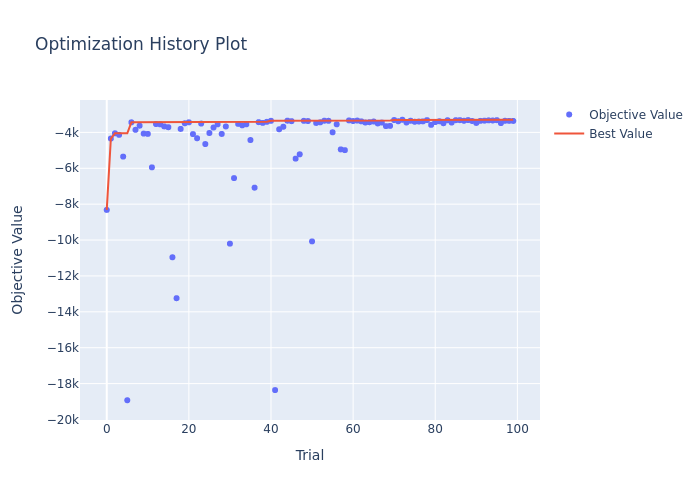

In [4]:
from IPython.display import Image, display

display(Image(filename="../outputs/optimization_history.png"))


## Hyperparameter Importance

This plot shows the relative importance of each hyperparameter in influencing
model performance. Parameters with higher importance had a stronger impact
on reducing prediction error.


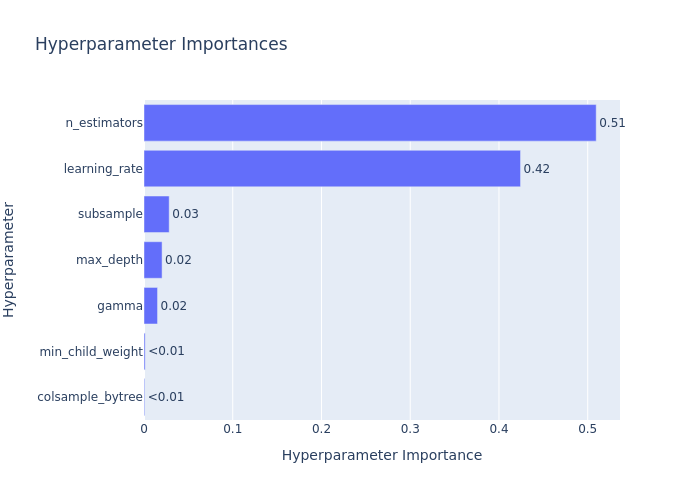

In [5]:
display(Image(filename="../outputs/param_importance.png"))


## Baseline vs Tuned Model Comparison

A baseline XGBoost model with default parameters was compared against the
Optuna-tuned model.

The tuned model shows improved performance due to better hyperparameter
selection, reduced overfitting, and more efficient learning behavior.


## Key Insights

- Optuna was able to efficiently explore the hyperparameter space within 100 trials.
- Learning rate, number of estimators, and tree depth had the most influence on performance.
- The MedianPruner helped reduce unnecessary evaluations of poor-performing trials.
- The tuned model achieved better generalization compared to the baseline.
- The optimization process was stable and reproducible.


## Conclusion

This analysis demonstrates how Optuna, combined with MLflow and XGBoost,
can be used to build a robust and reproducible hyperparameter optimization
pipeline.

The results highlight the importance of systematic tuning and experiment
tracking when developing machine learning models for real-world applications.
